In [1]:
import torch
import numpy as np
import matplotlib as plt
from src.datasets.mos2_sr import MOS2SRDataset

dataset = MOS2SRDataset()

# **1. GPR**
---

In [2]:
from src.models.prev_methods.gpr import GPR

model = GPR()

item        = dataset[0]
y           = item["y"]
y_sparse    = item["y_sparse"]
y_hat       = model(y_sparse)

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
y_hat = model(y_sparse)

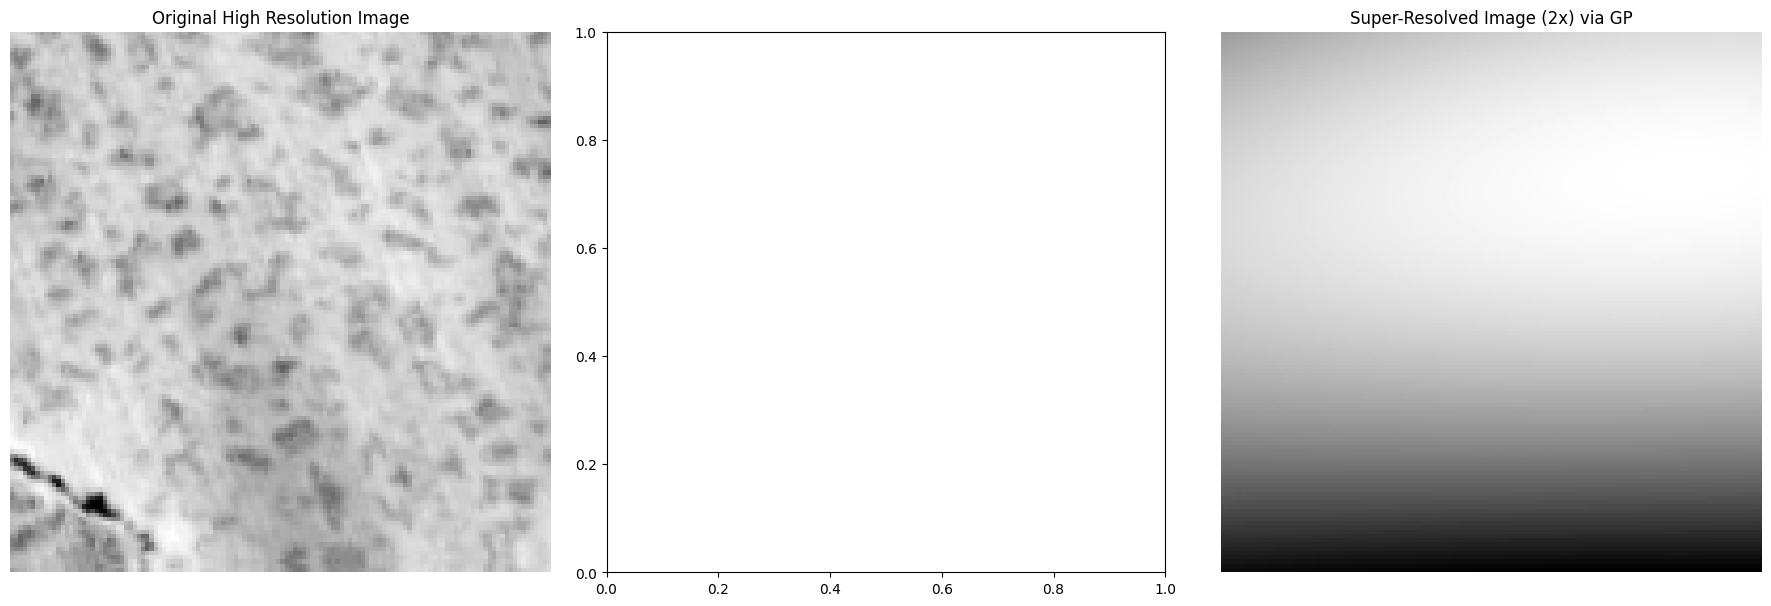

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# --------------------------
# Plot the results
# --------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original high resolution image
axes[0].imshow(y, cmap='gray')
axes[0].set_title('Original High Resolution Image')
axes[0].axis('off')

# # 2. Sparse observations
# # Here, to emphasize the sparse data, we use imshow for background and overlay the known points.
# axes[1].imshow(np.zeros_like(y_sparse), cmap='gray', vmin=0, vmax=1)
# sparse_coords = np.argwhere(~np.isnan(y_sparse))
# axes[1].scatter(sparse_coords[:, 1], sparse_coords[:, 0], c=y_sparse[~np.isnan(y_sparse)], cmap='gray')
# axes[1].set_title('Sparse Observations')
# axes[1].axis('off')

# 3. Super-resolved image from GP prediction
axes[2].imshow(y_hat, cmap='gray')
axes[2].set_title('Super-Resolved Image (2x) via GP')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# # Additionally, plot the GP prediction uncertainty (standard deviation)
# plt.figure(figsize=(6, 5))
# plt.imshow(y_std_img, cmap='viridis')
# plt.title('GP Prediction Uncertainty (Std. Dev.)')
# plt.colorbar()
# plt.axis('off')
# plt.show()